# RAPID-MFA-0: RAPID-MFA's conventions and common data structures

## Descriptions

All RAPID-MFA models share the same basic MFA model, with its modeling conventions, terminology, formats, and data structures.

This notebook details these basic building blocks and their logic. Some may be trivial or common to other MFA frameworks, but better have it explicit than assumed.

It includes Python codeblocks that resemble the code found in most RAPID-MFA, especially in section 4 (data structures) to exemplify these data structures and their initialization. However, it's recommended to read this side-by-side one of the basic RAPID-MFA notebooks for fuller context.

### Table of contents
1. [Terminology, equations, and conventions](#1-terminology-equations-and-conventions)
2. [Units of measurement](#2-units-of-measurement)
3. [Standard notebook contents](#3-standard-rapid-mfa-notebook-contents-and-formatting)
4. [Data structures](#4-rapid-mfa-data-structures)

### Relations with other RAPID-MFA notebooks
This notebook defines terminology, data structure types, variable names, etc. that appear in all other RAPID-MFA notebooks.

### Version, licence, and how to cite

Version 2026.7 - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

This notebook was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 


## 1. Terminology, equations, and conventions 

The foundations of the RAPID-MFA model framework
### 1.1 Time, timeframes, and time intervals
The RAPID MFA model describes an _**MFA system**_ of flows and stocks, and how these flows and stocks change over multiple _**timeframes**_. 

Each _**timeframe**_ $t$ describes one of a series of discrete _**time intervals**_, commonly 1 year, but could be any interval: a decade / two hours / five minutes.

> __Trivial convention:__ This means that a _timeframe_ accounts for the total flows that occured within this _time interval_: for example, all of the inflows and outflows that occured between January 1 and December 31 of the year, without detailing what happened in specific months or days within this _time interval_. \
\
__Non trivial convention:__ The **stocks are accounted for ("measured") at the end of the timeframe**, for example at the end of December 31st in the case of years. The logic is that this _stock_ is the summary of the activities that have occured within this _timeframe_. This end-of-period is also the convention of [ODYM](https://github.com/IndEcol/ODYM), [Flodym](https://flodym.readthedocs.io) and other common dynamic MFA modeling frameworks.

### 1.2 The static MFA system 

#### 1.2.1 Single-timeframe "snapshot" system definition

As simple as it gets: one _**inflow**_, one stock-accumulating process with a _**stock**_ and a _**stock change**_, and one _**outflow**_ within a single _timeframe_.


<svg width="299" height="98" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" overflow="hidden">
  <defs>
    <clipPath id="clip0">
      <rect x="0" y="0" width="299" height="98" />
    </clipPath>
  </defs>
  <g clip-path="url(#clip0)">
    <rect x="0" y="0" width="299" height="97.5045" fill="#FFFFFF" />
    <rect x="79" y="1.98987" width="142" height="94.5197" fill="#BFBFBF" />
    <path d="M1.99998 23.1325 60.5 23.1325 60.5 10.9444 85 35.3205 60.5 59.6967 60.5 47.5086 1.99998 47.5086Z" fill="#3891A7" fill-rule="evenodd" />
    <text fill="#FFFFFF" font-family="Calibri Light,Calibri Light_MSFontService,sans-serif" font-weight="300" font-size="18.6034" transform="matrix(1 0 0 0.994944 10.4285 41)">Inflows</text>
    <path d="M215 23.1325 273.5 23.1325 273.5 10.9444 298 35.3205 273.5 59.6967 273.5 47.5086 215 47.5086Z" fill="#FEB80A" fill-rule="evenodd" />
    <text fill="#FFFFFF" font-family="Calibri Light,Calibri Light_MSFontService,sans-serif" font-weight="300" font-size="18.6034" transform="matrix(1 0 0 0.994944 216.188 41)">Outflows</text>
    <rect x="96" y="44.7724" width="110" height="49.7472" fill="#C32D2E" />
    <text fill="#FFFFFF" font-family="Calibri Light,Calibri Light_MSFontService,sans-serif" font-weight="300" font-size="18.6034" transform="matrix(1 0 0 0.994944 126.92 75)">Stocks</text>
    <path d="M88 7.95959 140.19 7.95959C151.788 7.95959 161.19 17.3141 161.19 28.8534L161.19 37.4531 174 37.4531 152.465 55.7169 130.931 37.4531 143.741 37.4531 143.741 28.8534C143.741 26.9018 142.151 25.3198 140.19 25.3198L88 25.3199Z" fill="#967D42" fill-rule="evenodd" />
    <path d="M144 48.7522 144 28.2702C144 17.6925 152.618 9.11755 163.25 9.11755L195 9.11755 195 4.97468 206 17.0525 195 29.1302 195 24.9874 163.25 24.9874C161.428 24.9874 159.95 26.4571 159.95 28.2702L159.95 48.7522Z" fill="#967D42" fill-rule="evenodd" />
    <text fill="#FFFFFF" font-family="Calibri Light,Calibri Light_MSFontService,sans-serif" font-weight="300" font-size="18.6034" transform="matrix(1 0 0 0.994944 91.6914 22)">Stock changes</text>
  </g>
</svg>


> __Convention:__ The _system boundaries_ are assumed from the system definition. For example in the diagram above, the source of the inflows and the destination of the outflows are outside the system boundaries. 

Some RAPID-MFA models extend this simple system with more upstream or downstream processes and the flows between them, for example `RAPID-MFA-7a: Fixed recycling rate`.

#### 1.2.2 Mass balance
The mass balance equation of the basic system described above:
$$
\textcolor{#2A8596}{\text{inflows}(t)} = \textcolor{#D19F37}{\text{outflows}(t)} + \textcolor{#8E795E}{\text{stock\_changes}(t)} 
$$

> __Convention:__ This means that both _inflows_ and _outflows_ must be **non-negative numbers** (zeros or positive numbers). Negative values indicate that something went wrong!   \
On the other hand, _stock changes_ can certainly be negative values that describe a depleting stock.


### 1.3 Stock changes over time

The _stock changes_ also describe how the stocks evolve over time. This means that the _stock changes_ link the "static" mass balance aspect of the model with the "dynamic" time evolution aspect of the model.

> __Convention:__ The _stock changes_ variable is the difference between the stock of the __current__ timeframe $t$ and the __previous__ timeframe $t-1$ (i.e. not the difference with the next timeframe).

$$
\textcolor{#8E795E}{\text{stock\_changes}(t)} = \textcolor{#DC322F}{\text{stocks}(t)} - \textcolor{#DC322F}{\text{stocks}(t-1)}
$$

### 1.4 Cohorts, survival, and lifetimes

The vast majority of RAPID-MFA models use the cohorts "flavor" of dynamic MFA modeling.

An _inflow_ joins the _stocks_ as a new _**cohort**_ along with previously added _**cohorts**_ that are still part of the _**stock composition**_. 

> __Convention__: when an inflow becomes part of the stock, this inflow cohort's _**age**_ is **zero**. \
In the next _timeframe_, its _age_ grows by one _time interval_ (usually one year), and so forth. The newest inflow cohort is always the cohort of age zero, and the previous cohorts' ages increase by one. \
Two cohorts within the stock cannot have the same age. Cohorts cannot remain at the same age as time progresses. 

Each _cohort_ stays in the stock for some time, during which it gradually depletes: less and less of it is still in stock, generating some _outflow_ at every _timeframe_. The _cohort_'s residence behavior in the stock is described by its _**survival curve**_, while the gradual generation of outflow from the _cohort_ is described by its _**outflow generation curve**_. The relation between the _survival curve_ and _outflow generation curve_ is:

$$ 
\begin{align}
\textcolor{#FFa500}{\text{outflow\_generation\_curve}(t)} &= \left( \textcolor{#0000FF}{\text{survival\_curve}(t-1)} - \textcolor{#0000FF}{\text{survival\_curve}(t)} \right)  = | \Delta \textcolor{#0000FF}{\text{survival\_curve}(t)} |
\\
\textcolor{#0000FF}{\text{survival\_curve}(t)} &= 1 - \sum_{\tau=t_0}^{t} \textcolor{#FFa500}{\text{outflow\_generation\_curve}(\tau)}
\end{align}
$$

See `RAPID-MFA-5: A library of survival curves` for more information and practical use cases. 

> __Not a convention__: There's no reason to assume that all cohorts follow the same _survival curve_ (or _outflow generation curve_). Most of the basic RAPID MFA models assume so for simplicity, but the option to assign unique survival curves to each cohort is built-in. This is used in examples such as `RAPID-MFA-6a: One-off varying lifetime` and `RAPID-MFA-6b: Varying lifetime over time`.


## 2. Units of measurement

MFA systems can track different $units$ such as materials in mass (kg, tonnes, etc.), products (cars, chairs, computers), service units (m^2^ of floor space).

- __Flows__ including the _stock changes_ are measured in $\frac{unit}{time\_interval}$. 

- __Stocks__ are measured in $units$.

- __Transfer coefficients__ split a single flow into multiple flows with separate destination processes, measured in rates from 0 to 1 or percentages.

An MFA system can track both the products's flows and stocks and the corresponding flows and stocks of the product's constituent materials.

- __Intensities__ are coefficients and ratios that convert between different units, e.g. __material intensities__ in $\frac{mass}{unit}$.

Time dimensions:

- __Time frames__ are measured in units of _time intervals_, for example calendar years.

- The __cohort age__ of each cohort is measured in units of _time intervals_ from age zero (in the year of inflow) onward, of the time that has passed since the inflow originally occured.

- __Cohorts__ of previous and new inflows in the stocks (and in the outflows) are uniquely indexed and identified by the _time frame_ when each of them was an inflow, for example the calendar year in which the inflow occured.

- A __Survival curve__'s time dimension (horizontal axis) forms the basis for the _cohort age_, measured in units of _time intervals_ starting from zero. Its _value_ (vertical axis) of the survival curve is a monotonically decreasing rate ("percentage of the inflow") between 1 and 0, and either decreases over time or remains the same. It cannot increase.

- An __Outflow generation curve__'s time dimension (horizontal axis) forms the basis for the _cohort age_, measured in units of _time intervals_ starting from zero. Its _value_ (vertical axis) is measured in rates ("percentage of the inflow")  which can increase, decrease, or stay the same, and should sum up over time towards 1.

## 3. Standard RAPID-MFA notebook contents and formatting

This section describes what to expect to find in RAPID-MFA notebooks.

**Run this section's codeblocks to be able to also run the codes in the next [Data Structures](#4-data-structures) section**.

### Introductory Markdown descriptions

#### Basic descriptions

The introductory descriptions contain basic explanations about the notebook's model, contents, and use cases, sometimes accompanied by equations and visuals.

#### Notes

The notes subsection covers important details about both the general model (or how to generalize it) and about the specific example.

#### The exogenous input variables used in this example

Lists the sources and further information about the input data that are used to exemplify the notebook's model.

> To keep RAPID-MFA examples focused and simple, the example input data are provided as inline typed-in direct inputs, without importing external data such as CSV or Excel files. This is in similar style of the documentation user guides and API references of [Pandas](https://pandas.pydata.org/pandas-docs/stable/index.html), [NumPy](https://numpy.org/doc/stable/index.html) and many others. \
**Of course the user can - and should - change this to import their own data.**

#### Relations with other RAPID-MFA notebooks

Lists RAPID-MFA notebooks that the notebook directly uses, compares against, or develops further.

> As a rule of thumb, only dependencies (i.e. more basic RAPID-MFA models) are described by name. More advanced models that this notebook forms the basis to are not mentioned by name.

#### Version, licence, and how to cite

Version _YYYY.M_ - check the [RAPID MFA GitHub repository](https://github.com/TomerFishman/RAPID-MFA/) for changes, history, and updates.

> Versioning is by time: YYYY = year and M = month. \
Minor edits / versions that don't change fundamental actions are documented as GitHub commits, without new version numbers.

This code was created and is maintained by the [RAPID MFA development team](https://github.com/TomerFishman/RAPID-MFA/tree/master#contributors-and-acknowledgements).

This notebook is <a href="https://creativecommons.org/licenses/by-nc/4.0"><img src="https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc.png" alt="CC-BY-NC" width="70"> CC-BY-NC</a>, meaning you can - and should! - freely reuse and adapt this code for noncommercial purposes __as long as you attribute this source__. 

### Initialization Python code

All RAPID-MFA notebooks' codes start with similar initialization sections:
- **Load libraries**: Required libraries and packages. Some might be optional and not for the core functioning of the specific notebook (e.g. Seaborn / sns for visualizations).
- **Define example input data**: Should be replaced by the user with their own data. Also see the note in [The exogenous input variables used in this example](#the-exogenous-input-variables-used-in-this-example) above.

In [9]:
# %% 1. Load libraries
import numpy as np
import pandas as pd
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

These are followed by Notebook-specific codeblocks and Markdown description blocks, usually:
- Setting up the MFA system (see data structures below)
- Calculating the full MFA system
- Visualizations, diagnosis, and further remarks

## 4. RAPID-MFA data structures

This section describes the commmon parameters, variables, and data structures of RAPID-MFA. It includes Python codeblocks that resemble the code found in most RAPID-MFA to exemplify these data structures and their initialization. However, it's recommended to read this side-by-side one of the basic RAPID-MFA notebooks for fuller context.

The main data structures in RAPID-MFA, `mfa_system` and `survival_matrix` are Pandas dataframes:
- Intuitive two-dimensional tables that resemble Excel and CSV lower the learning curve.
- Dataframe row and column indexes are easy and useful to name, refer to, edit, and slice. 
- Multiindex enables expansion to more optional dimensions without losing the simple 2d structure.

> **Convention**: In RAPID-MFA, **timeframes are the rows of dataframes** because they are the basic objects of study / datapoints / "observations" / "samples" / instances of the MFA system at different points in time, whereas the columns are components / attributes / features of the MFA system  i.e. its state within that timeframe.



### 4.1 Basic parameters

> These parameters are usually defined in the **Set up the MFA system** code block, immediately following the **Define example input data** codeblock. \
\
This code block should be included in any usage, edit, and modification of RAPID-MFA models, unlike optional code that precede it.

`units` is a _dictionary_ of the units of measurement of the system. The three basic units are *time_interval*, _flows_, and _stocks_. Should be changed by the user to accomodate their modeling requirements.


In [18]:
units = {'time_interval': 'year', 
         'flows':         'kg/year', 
         'stocks':        'kg'}


`time_interval` is the interval between `timeframes`, `cohorts` and `ages` (see below), often 1 year or 1 month etc. Usually an _integer_.

In [19]:
time_interval = 1 # Interval between timeframes, often 1 year or 1 month etc.

`timeframes` is the index of the "snapshots" of the system in every _time interval_, e.g. calendar years from 1950 to 2050. It is a _one-dimensional array-like (list, range, index, series, etc.)_ of a serial nature.

`cohorts` is the index of the inflows that enter the system in every _time interval_. It is a _one-dimensional array-like (list, range, index, series, etc.)_ of a serial nature. 

> `cohorts` is usually identical to `timeframes`, as in the example below, but may be longer in cases like initial stocks with a known composition, truncated spin-up period, and other cases in which the model tracks more cohorts than those that entered the stocks during the period of interest.

> Note that the `timeframes` in the example below covers the years 1950-2050, and should be changed to the user's requirements.

In [44]:
timeframes = cohorts = list(range(1950, 2019, time_interval))  # timeframes are the "snapshots" of the system in every time interval, while cohorts are the inflows that enter the system in every time interval. They are the same because we have one inflow per time interval.


`cohort_stop` is one extra time_interval beyond the end of the _cohorts_ index, required because of "exclusive slicing" in Python. Without it, some actions would skip the last index entry. Usually an _integer_.


In [45]:
cohort_stop = (cohorts[-1] + time_interval)  # because of exclusive slicing in python, an extra time interval is required


### 4.2 The MFA system DataFrame

`MFA system` describes the flows and stocks of the modeled system over time. 

It is a Pandas DataFrame with an _index_ of `timeframes` and _columns_ including **at least** the _stocks_, _inflows_, _outflows_, and *stock_changes*.

This data structure is intentionally kept simple, so there are no internal checks and users must check consistencies on their own for things like:
- The stocks have a different unit of measurement than the inflows, outflows, and stock changes
- Mass balance

Further columns can be added by the user, such as:
- More flows, stocks, and processes. 
- Auxiliary columns like transfer coefficients or material intensities
- Convert to multiindex columns for the flows and stocks multiple materials, products, etc.

Multiple MFA systems dataframes can be created and modeled in RAPID-MFA, for instance one for each material or product, one for each region, etc. Whether to create multiple MFA systems or to use multiindex in a single system is left to the user.

> __Convention:__  It's recommended to store the products layer and the materials layer as two separate dataframes to avoid too much mixing of units of measurement. See an example in `RAPID-MFA-9: Switching from products/services to materials`. However, this is left to the user discretion.

In [46]:
mfa_system = pd.DataFrame(index = timeframes, columns = ['stocks',
                                                         'inflows', 
                                                         'outflows', 
                                                         'stock_changes'])

<svg width="907" height="219" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" overflow="hidden">
  <defs>
    <clipPath id="clip0">
      <rect x="0" y="0" width="907" height="219" />
    </clipPath>
  </defs>
  <g clip-path="url(#clip0)">
    <rect x="0" y="0" width="907" height="218.874" fill="#FFFFFF" />
    <path d="M156.631-0.816072 213.154-0.816072 213.154 47.1474 156.631 47.1474Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M213.154-0.816072 343.658-0.816072 343.658 47.1474 213.154 47.1474Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M343.658-0.816072 474.162-0.816072 474.162 47.1474 343.658 47.1474Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M474.162-0.816072 604.667-0.816072 604.667 47.1474 474.162 47.1474Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M604.667-0.816072 735.171-0.816072 735.171 47.1474 604.667 47.1474Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M735.171-0.816072 907-0.816072 907 47.1474 735.171 47.1474Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M156.631 47.1474 213.154 47.1474 213.154 75.9255 156.631 75.9255Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M213.154 47.1474 343.658 47.1474 343.658 75.9255 213.154 75.9255Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M343.658 47.1474 474.162 47.1474 474.162 75.9255 343.658 75.9255Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M474.162 47.1474 604.667 47.1474 604.667 75.9255 474.162 75.9255Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M604.667 47.1474 735.171 47.1474 735.171 75.9255 604.667 75.9255Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M735.171 47.1474 907 47.1474 907 75.9255 735.171 75.9255Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M156.631 75.9255 213.154 75.9255 213.154 104.704 156.631 104.704Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M213.154 75.9255 343.658 75.9255 343.658 104.704 213.154 104.704Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M343.658 75.9255 474.162 75.9255 474.162 104.704 343.658 104.704Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M474.162 75.9255 604.667 75.9255 604.667 104.704 474.162 104.704Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M604.667 75.9255 735.171 75.9255 735.171 104.704 604.667 104.704Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M735.171 75.9255 907 75.9255 907 104.704 735.171 104.704Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M156.631 104.704 213.154 104.704 213.154 133.482 156.631 133.482Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M213.154 104.704 343.658 104.704 343.658 133.482 213.154 133.482Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M343.658 104.704 474.162 104.704 474.162 133.482 343.658 133.482Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M474.162 104.704 604.667 104.704 604.667 133.482 474.162 133.482Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M604.667 104.704 735.171 104.704 735.171 133.482 604.667 133.482Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M735.171 104.704 907 104.704 907 133.482 735.171 133.482Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M156.631 133.482 213.154 133.482 213.154 162.26 156.631 162.26Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M213.154 133.482 343.658 133.482 343.658 162.26 213.154 162.26Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M343.658 133.482 474.162 133.482 474.162 162.26 343.658 162.26Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M474.162 133.482 604.667 133.482 604.667 162.26 474.162 162.26Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M604.667 133.482 735.171 133.482 735.171 162.26 604.667 162.26Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M735.171 133.482 907 133.482 907 162.26 735.171 162.26Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M156.631 162.26 213.154 162.26 213.154 191.038 156.631 191.038Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M213.154 162.26 343.658 162.26 343.658 191.038 213.154 191.038Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M343.658 162.26 474.162 162.26 474.162 191.038 343.658 191.038Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M474.162 162.26 604.667 162.26 604.667 191.038 474.162 191.038Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M604.667 162.26 735.171 162.26 735.171 191.038 604.667 191.038Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M735.171 162.26 907 162.26 907 191.038 735.171 191.038Z" fill="#CEDCE1" fill-rule="evenodd" />
    <path d="M156.631 191.038 213.154 191.038 213.154 219.816 156.631 219.816Z" fill="#3891A7" fill-rule="evenodd" />
    <path d="M213.154 191.038 343.658 191.038 343.658 219.816 213.154 219.816Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M343.658 191.038 474.162 191.038 474.162 219.816 343.658 219.816Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M474.162 191.038 604.667 191.038 604.667 219.816 474.162 219.816Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M604.667 191.038 735.171 191.038 735.171 219.816 604.667 219.816Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M735.171 191.038 907 191.038 907 219.816 735.171 219.816Z" fill="#E8EEF1" fill-rule="evenodd" />
    <path d="M213.154-1.48223 213.154 220.482" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M343.658-1.48223 343.658 220.482" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M474.162-1.48223 474.162 220.482" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M604.667-1.48223 604.667 220.482" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M735.171-1.48223 735.171 220.482" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M155.964 47.1474 907.667 47.1474" stroke="#FFFFFF" stroke-width="3.99927" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M155.964 75.9255 907.667 75.9255" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M155.964 104.704 907.667 104.704" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M155.964 133.482 907.667 133.482" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M155.964 162.26 907.667 162.26" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M155.964 191.038 907.667 191.038" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.631-1.48223 156.631 220.482" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M907-1.48223 907 220.482" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M155.964-0.816072 907.667-0.816072" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M155.964 219.816 907.667 219.816" stroke="#FFFFFF" stroke-width="1.33309" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 755.408 19)">(additional flows or</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 796.033 38)">stocks)</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 617.992 19)">stock_changes</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 509.71 19)">outflows</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 384.288 19)">inflows</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 255.69 19)">stocks</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 166.229 67)">1950</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 166.229 96)">1951</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 166.229 124)">1952</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 166.229 153)">…</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 166.229 182)">2018</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="15.9878" transform="matrix(1 0 0 0.999423 166.229 211)">2019</text>
    <path d="M149 213.877C140.992 213.877 134.5 212.795 134.5 211.461L134.5 133.839C134.5 132.505 128.008 131.424 120 131.424 128.008 131.424 134.5 130.343 134.5 129.009L134.5 51.3869C134.5 50.0531 140.992 48.9718 149 48.9718" stroke="#000000" stroke-width="1.99963" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="18.6525" transform="matrix(1 0 0 0.999423 22.8178 136)">timeframes</text>
    <path d="M0 0 53.6716 4.094" stroke="#000000" stroke-width="1.99848" stroke-miterlimit="8" fill="none" fill-rule="evenodd" transform="matrix(1.00058 0 0 -1 110 91.0438)" />
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="18.6525" transform="matrix(1 0 0 0.999423 24.1963 96)">timeframe</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="18.6525" transform="matrix(1 0 0 0.999423 60.3594 116)">in</text>
    <path d="M155 206.881C151.41 206.881 148.5 206.396 148.5 205.798L148.5 191.473C148.5 190.875 145.59 190.39 142 190.39 145.59 190.39 148.5 189.905 148.5 189.307L148.5 174.982C148.5 174.384 151.41 173.9 155 173.9" stroke="#7F7F7F" stroke-width="1.99963" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
    <path d="M142.37 189.988 110 185.893" stroke="#7F7F7F" stroke-width="1.99963" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
    <text fill="#7F7F7F" font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="18.6525" transform="matrix(1 0 0 0.999423 2.42365 190)">time_interval</text>
    <path d="M110 96.9441 163.703 115.422" stroke="#000000" stroke-width="1.99963" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
  </g>
</svg>

### 4.3 Ages, survival curves and outflow generation curves array-like

`ages` is a _one-dimensional array-like (list, range, index, series, etc.)_ that starts at zero, has the same length as _timeframes_ and _cohorts_, and is in intervals of `time_interval`. It describes the time that has passed since a cohort started its life as an inflow, from age zero (the _timeframe_ in which the inflow occured) onwards.

`survival curve` and `outflow generation curve` are _one-dimensional array-like (list, range, index, series, etc.)_. If using a Pandas series, its index is `ages`. In other data types the index starts from zero anyway. Their individual items should be floating-point numbers between 1 and 0, see [section 1.4](#14-cohorts-survival-and-lifetimes) above for further details. Usually only one of them is used in a dynamic MFA model.

> Note that the `survival curve` in the example below uses mock parameter values, and should be changed to the user's requirements. It could also be made from values imported from a CSV file, a custom function, etc.

(0.0, 1.1)

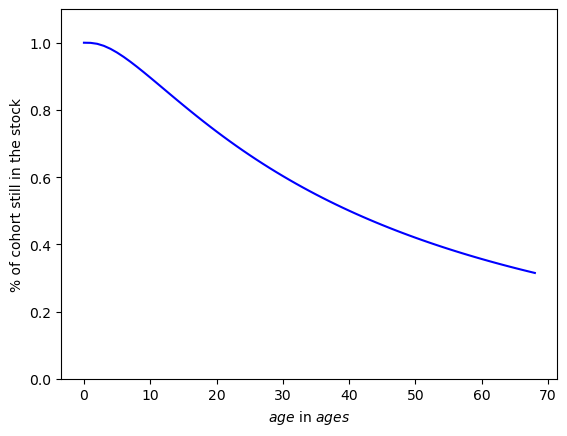

In [61]:
ages = range(0, len(timeframes))

survival_curve = scipy.stats.lognorm.sf(ages, s = 1.1, loc = 0, scale = 40)

plt.plot(ages, survival_curve,  color='blue')
plt.xlabel('$\it{age}$ in $\it{ages}$')
plt.ylabel('% of cohort still in the stock')
plt.ylim(0,1.1)


### 4.4 Cohort matrices: survival curve matrix, cohort survival matrix

(As well as outflow generation matrix and cohort outflow matrix, and other data structures that describe attributes by cohorts)

A `cohort matrix` is a Dataframe with an _index_ of `timeframes`, and _columns_ of `cohorts`.

> **Convention**: This Data Structure maintains the RAPID-MFA convention of _timeframes_ being the rows. The columns describe the _state_ of some attribute of each of the cohorts at any given _timeframe_.

- It is a _[lower triangular matrix](https://en.wikipedia.org/wiki/Triangular_matrix)_: the upper triangle above the diagonal is by definition zeros, because it describes cohorts that "haven't occured" yet. The diagonal is the initial state of some attribute of the cohort in its year of inflow. In the lower triangle, following the cohort down its own column describes its changed state as its _age_ increases from one _timeframe_ to the next. 

Usually, though not always:
- The `survival curve matrix` is _usually_ a square (equal length of rows and columns), but can have more columns than rows when there are more cohorts than the time period being studied, e.g. after a truncated spin-up period, a known initial stock composition, etc.

The two most common instances of the `cohort matrix` are the `survival curve matrix` and `cohort survival matrix`


<svg width="694" height="242" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink" overflow="hidden">
  <defs>
    <clipPath id="clip0">
      <rect x="0" y="0" width="694" height="242" />
    </clipPath>
  </defs>
  <g clip-path="url(#clip0)">
    <rect x="0" y="0" width="694" height="241.992" fill="#FFFFFF" />
    <path d="M156.92 39.1004 210.518 39.1004 210.518 67.9203 156.92 67.9203Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M210.518 39.1004 291.098 39.1004 291.098 67.9203 210.518 67.9203Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M291.098 39.1004 371.679 39.1004 371.679 67.9203 291.098 67.9203Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M371.679 39.1004 452.259 39.1004 452.259 67.9203 371.679 67.9203Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M452.259 39.1004 532.839 39.1004 532.839 67.9203 452.259 67.9203Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M532.839 39.1004 613.42 39.1004 613.42 67.9203 532.839 67.9203Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M613.42 39.1004 694 39.1004 694 67.9203 613.42 67.9203Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M156.92 67.9203 210.518 67.9203 210.518 96.7401 156.92 96.7401Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M210.518 67.9203 291.098 67.9203 291.098 96.7401 210.518 96.7401Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M291.098 67.9203 371.679 67.9203 371.679 96.7401 291.098 96.7401Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M371.679 67.9203 452.259 67.9203 452.259 96.7401 371.679 96.7401Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M452.259 67.9203 532.839 67.9203 532.839 96.7401 452.259 96.7401Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M532.839 67.9203 613.42 67.9203 613.42 96.7401 532.839 96.7401Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M613.42 67.9203 694 67.9203 694 96.7401 613.42 96.7401Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M156.92 96.7401 210.518 96.7401 210.518 125.56 156.92 125.56Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M210.518 96.7401 291.098 96.7401 291.098 125.56 210.518 125.56Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M291.098 96.7401 371.679 96.7401 371.679 125.56 291.098 125.56Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M371.679 96.7401 452.259 96.7401 452.259 125.56 371.679 125.56Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M452.259 96.7401 532.839 96.7401 532.839 125.56 452.259 125.56Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M532.839 96.7401 613.42 96.7401 613.42 125.56 532.839 125.56Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M613.42 96.7401 694 96.7401 694 125.56 613.42 125.56Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M156.92 125.56 210.518 125.56 210.518 154.38 156.92 154.38Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M210.518 125.56 291.098 125.56 291.098 154.38 210.518 154.38Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M291.098 125.56 371.679 125.56 371.679 154.38 291.098 154.38Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M371.679 125.56 452.259 125.56 452.259 154.38 371.679 154.38Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M452.259 125.56 532.839 125.56 532.839 154.38 452.259 154.38Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M532.839 125.56 613.42 125.56 613.42 154.38 532.839 154.38Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M613.42 125.56 694 125.56 694 154.38 613.42 154.38Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M156.92 154.38 210.518 154.38 210.518 183.2 156.92 183.2Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M210.518 154.38 291.098 154.38 291.098 183.2 210.518 183.2Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M291.098 154.38 371.679 154.38 371.679 183.2 291.098 183.2Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M371.679 154.38 452.259 154.38 452.259 183.2 371.679 183.2Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M452.259 154.38 532.839 154.38 532.839 183.2 452.259 183.2Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M532.839 154.38 613.42 154.38 613.42 183.2 532.839 183.2Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M613.42 154.38 694 154.38 694 183.2 613.42 183.2Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M156.92 183.2 210.518 183.2 210.518 212.02 156.92 212.02Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M210.518 183.2 291.098 183.2 291.098 212.02 210.518 212.02Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M291.098 183.2 371.679 183.2 371.679 212.02 291.098 212.02Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M371.679 183.2 452.259 183.2 452.259 212.02 371.679 212.02Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M452.259 183.2 532.839 183.2 532.839 212.02 452.259 212.02Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M532.839 183.2 613.42 183.2 613.42 212.02 532.839 212.02Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M613.42 183.2 694 183.2 694 212.02 613.42 212.02Z" fill="#E9CDCD" fill-rule="evenodd" />
    <path d="M156.92 212.02 210.518 212.02 210.518 240.839 156.92 240.839Z" fill="#C32D2E" fill-rule="evenodd" />
    <path d="M210.518 212.02 291.098 212.02 291.098 240.839 210.518 240.839Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M291.098 212.02 371.679 212.02 371.679 240.839 291.098 240.839Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M371.679 212.02 452.259 212.02 452.259 240.839 371.679 240.839Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M452.259 212.02 532.839 212.02 532.839 240.839 452.259 240.839Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M532.839 212.02 613.42 212.02 613.42 240.839 532.839 240.839Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M613.42 212.02 694 212.02 694 240.839 613.42 240.839Z" fill="#F5E8E8" fill-rule="evenodd" />
    <path d="M210.518 38.4333 210.518 241.506" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M291.098 38.4333 291.098 241.506" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M371.679 38.4333 371.679 241.506" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M452.259 38.4333 452.259 241.506" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M532.839 38.4333 532.839 241.506" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M613.42 38.4333 613.42 241.506" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.253 67.9203 694.667 67.9203" stroke="#FFFFFF" stroke-width="4.00288" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.253 96.7401 694.667 96.7401" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.253 125.56 694.667 125.56" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.253 154.38 694.667 154.38" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.253 183.2 694.667 183.2" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.253 212.02 694.667 212.02" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.92 38.4333 156.92 241.506" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M694 38.4333 694 241.506" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.253 39.1004 694.667 39.1004" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <path d="M156.253 240.839 694.667 240.839" stroke="#FFFFFF" stroke-width="1.33429" stroke-linejoin="round" stroke-miterlimit="10" fill="none" fill-rule="evenodd" />
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 636.698 59)">2019</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 556.117 59)">2018</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 485.961 59)">…</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 394.956 59)">1952</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 314.376 59)">1951</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 233.796 59)">1950</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 649.457 88)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 568.876 88)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 488.296 88)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 407.716 88)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 327.135 88)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 227.485 88)">(value)</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 166.527 88)">1950</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 649.457 117)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 568.876 117)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 488.296 117)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 407.716 117)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 308.065 117)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 227.485 117)">(value)</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 166.527 117)">1951</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 649.457 145)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 568.876 145)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 488.296 145)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 388.645 145)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 308.065 145)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 227.485 145)">(value)</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 166.527 145)">1952</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 649.457 174)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 568.876 174)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 469.226 174)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 388.645 174)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 308.065 174)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 227.485 174)">(value)</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 166.527 174)">…</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 649.457 203)">0</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 549.806 203)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 469.226 203)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 388.645 203)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 308.065 203)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 227.485 203)">(value)</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 166.527 203)">2018</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 630.386 232)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 549.806 232)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 469.226 232)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 388.645 232)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 308.065 232)">(value)</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 227.485 232)">(value)</text>
    <text fill="#FFFFFF" font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="16.011" transform="matrix(1 0 0 0.999968 166.527 232)">2019</text>
    <path d="M149 238.992C141.268 238.992 135 237.948 135 236.659L135 158.328C135 157.04 128.732 155.995 121 155.995 128.732 155.995 135 154.95 135 153.662L135 75.3307C135 74.0422 141.268 72.9977 149 72.9977" stroke="#000000" stroke-width="2.00144" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="18.6795" transform="matrix(1 0 0 0.999968 22.8545 161)">timeframes</text>
    <path d="M0 0 53.7495 4.09994" stroke="#000000" stroke-width="2.00138" stroke-miterlimit="8" fill="none" fill-rule="evenodd" transform="matrix(1.00003 0 0 -1 110 116.096)" />
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="18.6795" transform="matrix(1 0 0 0.999968 24.2343 121)">timeframe</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="18.6795" transform="matrix(1 0 0 0.999968 60.4298 141)">in</text>
    <path d="M155 231.993C151.41 231.993 148.5 231.508 148.5 230.909L148.5 216.576C148.5 215.978 145.59 215.493 142 215.493 145.59 215.493 148.5 215.008 148.5 214.41L148.5 200.077C148.5 199.479 151.41 198.994 155 198.994" stroke="#7F7F7F" stroke-width="2.00144" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
    <path d="M142.399 215.094 110 210.993" stroke="#7F7F7F" stroke-width="2.00144" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
    <text fill="#7F7F7F" font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="18.6795" transform="matrix(1 0 0 0.999968 2.4416 215)">time_interval</text>
    <path d="M110 121.996 163.751 140.501" stroke="#000000" stroke-width="2.00144" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="18.6795" transform="matrix(1 0 0 0.999968 344.946 16)">cohort</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-weight="400" font-size="18.6795" transform="matrix(1 0 0 0.999968 409.325 16)">in</text>
    <text font-family="Aptos,Aptos_MSFontService,sans-serif" font-style="italic" font-weight="400" font-size="18.6795" transform="matrix(1 0 0 0.999968 431.842 16)">cohorts</text>
    <path d="M213 36.9988C213 32.0283 213.671 27.9989 214.5 27.9989L450 27.9994C450.829 27.9994 451.5 23.97 451.5 18.9994 451.5 23.97 452.171 27.9994 453 27.9994L688.5 27.9994C689.329 27.9994 690 32.0288 690 36.9993" stroke="#000000" stroke-width="2.00138" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
    <path d="M0 0 42.6908 25.5441" stroke="#000000" stroke-width="2.00138" stroke-miterlimit="8" fill="none" fill-rule="evenodd" transform="matrix(1.00003 0 0 -1 333 44.5435)" />
    <path d="M408.264 44.7474 384 18.9994" stroke="#000000" stroke-width="2.00144" stroke-miterlimit="8" fill="none" fill-rule="evenodd" />
  </g>
</svg>

#### The survival curve matrix

Each of the columns is the survival curve of the cohort, _shifted_ down on the diagonal and trimmed at its end to fit down until the last row (timeframe) of the _survival curve matrix_. 

- The survival curves in each column are _usually_ identical, i.e. all cohorts use the same survival curve. In such a case, the `survival curves matrix` becomes a _[Toeplitz matrix](https://en.wikipedia.org/wiki/Toeplitz_matrix)_. See `RAPID-MFA-6b: Varying lifetime over time` for an example with differing survival curves, when this is not a Toeplitz matrix.
- The `outflow generation curves matrix` is the equivalent that uses _outflow generation curves_. See `RAPID-MFA-3: The flow driven model using an outflow generation curve` and `RAPID-MFA-4: The stock driven model using an outflow generation curve for examples`.

In [62]:
# %% Create the survival curves matrix
# create survival curves matrix filled with zeros
survival_curves_matrix = pd.DataFrame(0, index=timeframes, columns=cohorts, dtype=float)

# and populate that matrix
for cohort in cohorts:
    # at each iteration, shift the survival curve and fill the next column of the survival curves matrix with the shifted survival curve from the diagonal downwards.
    survival_curves_matrix.loc[cohort: , cohort] = survival_curve[0 : cohort_stop - cohort]

survival_curves_matrix

,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
1950,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1951,0.999601,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1952,0.996769,0.999601,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1953,0.990733,0.996769,0.999601,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
1954,0.981837,0.990733,0.996769,0.999601,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014,0.334589,0.339818,0.345163,0.350626,0.356211,0.361922,0.367763,0.373736,0.379847,0.386098,...,0.970648,0.981837,0.990733,0.996769,0.999601,1.000000,0.000000,0.000000,0.000000,0.0
2015,0.329472,0.334589,0.339818,0.345163,0.350626,0.356211,0.361922,0.367763,0.373736,0.379847,...,0.957705,0.970648,0.981837,0.990733,0.996769,0.999601,1.000000,0.000000,0.000000,0.0
2016,0.324465,0.329472,0.334589,0.339818,0.345163,0.350626,0.356211,0.361922,0.367763,0.373736,...,0.943462,0.957705,0.970648,0.981837,0.990733,0.996769,0.999601,1.000000,0.000000,0.0
2017,0.319563,0.324465,0.329472,0.334589,0.339818,0.345163,0.350626,0.356211,0.361922,0.367763,...,0.928283,0.943462,0.957705,0.970648,0.981837,0.990733,0.996769,0.999601,1.000000,0.0


#### The cohorts survival matrix

The structure is identical to the above, and each of the columns describes the amount of still-surviving amount of the cohort within the stocks at any _timeframe_. Each column is the value of the equivalent column (cohort) of the `survival curve matrix`, _scaled_ (multiplied) by the corresponding _inflow_.
- If the _inflows_ are already known, see `RAPID-MFA-1: The flow driven model` for an example of creating the cohort survival matrix directly as explained above.
- If the _inflows_ are not yet known but the stocks are known, see `RAPID-MFA-2: The stock driven model` for an example of creating the cohort survival matrix by iteratively estimating the inflows one cohort at a time.
- The `cohorts outflows matrix` is the equivalent that uses _outflow generation curves_. See `RAPID-MFA-3: The flow driven model using an outflow generation curve` and `RAPID-MFA-4: The stock driven model using an outflow generation curve for examples`.
